# Common Libraries

In [7]:
import os, sys, shutil, mediapy
import numpy as np

if shutil.which('nvidia-smi') is not None:
    os.environ['MUJOCO_GL'] = 'egl'
import mujoco

# Custom Libraries

In [2]:
from pathlib import Path
sys.path.append("/home/seojin/Seojin_commonTool/Module/XML")

from xml_util import make_graph_image

# Paths

In [3]:
osim_dir_path = "/home/seojin/myoconverter/models/osim/Arm26"

osim_file = os.path.join(osim_dir_path, "arm26.osim")
geometry_folder = os.path.join(osim_dir_path, "Geometry")
converted_model_path = os.path.join("/mnt/ext1/seojin/temp/arm26", "arm26_cvt3_woC.xml")

output_dir_path = "/mnt/ext1/seojin/temp"

# Visualize xml graph

In [12]:
# Osim model
make_graph_image(xml_path = osim_file, 
                 output_dir_path = output_dir_path)

# Mujoco model
make_graph_image(xml_path = converted_model_path, 
                 output_dir_path = output_dir_path)

/mnt/ext1/seojin/temp/arm26_treeData.dot is made completely!
/mnt/ext1/seojin/temp/arm26_treeFig.png is made completely!
/mnt/ext1/seojin/temp/arm26_cvt3_treeData.dot is made completely!
/mnt/ext1/seojin/temp/arm26_cvt3_treeFig.png is made completely!


# Render

""

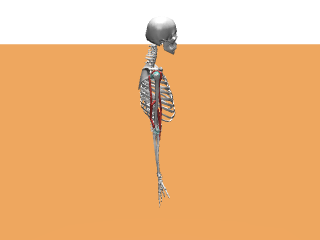

In [14]:
model = mujoco.MjModel.from_xml_path(converted_model_path)
data = mujoco.MjData(model)

cam = mujoco.MjvCamera()
with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)

    cam.azimuth = 90
    cam.elevation = -20
    cam.distance = 1.7
    cam.lookat = np.array([0, 0, 0.5])
    renderer.update_scene(data, camera=cam)

    mediapy.show_image(renderer.render())